### Compare Precipiation from Stations and HRRR-AK

Notebook contents 
* pulling the HRRR-AK Data processed into UTM already in `2_clean_hrrrak_netcdf.ipynb` and comparing with Powder Patch in-situ data

created by Cassie Lumbrazo\
last updated: Feb 2026\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import dates
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

In [2]:
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

In [3]:
pwd

'/home/cassie/python/repos/snow_model_forcing'

# Load HRRR-AK Data

In [4]:
input_file = '/hdd/snow_hydrology/hrrrak/small_juneau_domain/netcdf/hrrrak_merged_grib_f567_WY2024_test1_utm_pp.nc'
ds = xr.open_dataset(input_file)

# write the crs 
ds.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work
ds

<xarray.Dataset> Size: 781kB
Dimensions:                  (time: 3311)
Coordinates:
  * time                     (time) datetime64[ns] 26kB 2023-10-01T05:00:00 ....
    valid_time               (time) datetime64[ns] 26kB ...
    step                     (time) timedelta64[ns] 26kB ...
    x                        float64 8B ...
    y                        float64 8B ...
    boundaryLayerCloudLayer  float64 8B ...
    spatial_ref              int64 8B 0
Data variables: (12/53)
    pt                       (time) float32 13kB ...
    temp                     (time) float32 13kB ...
    d2m                      (time) float32 13kB ...
    sh2                      (time) float32 13kB ...
    rh                       (time) float32 13kB ...
    u10                      (time) float32 13kB ...
    ...                       ...
    vgtyp                    (time) float32 13kB ...
    cloud_total              (time) float32 13kB ...
    cloud_high               (time) float32 13kB ...
    cloud_low                (time) float32 13kB ...
    wind                     (time) float32 13kB ...
    temp_c                   (time) float32 13kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

### Precipitation Variables from HRRR-AK
`ds.tp` accumulated precipitation since forecast start\
units: kg/m²\
range: 0–20

`ds.precip_rate` is the precipiation rate\
units: kg/m²/s\
range: 0–0.0035

Then, we can create a variable, which would be used in the model, which is the `precip_rate` accumulated over the model timestep (i.e., 1 hr)\
`ds.precip_accum_1hr`

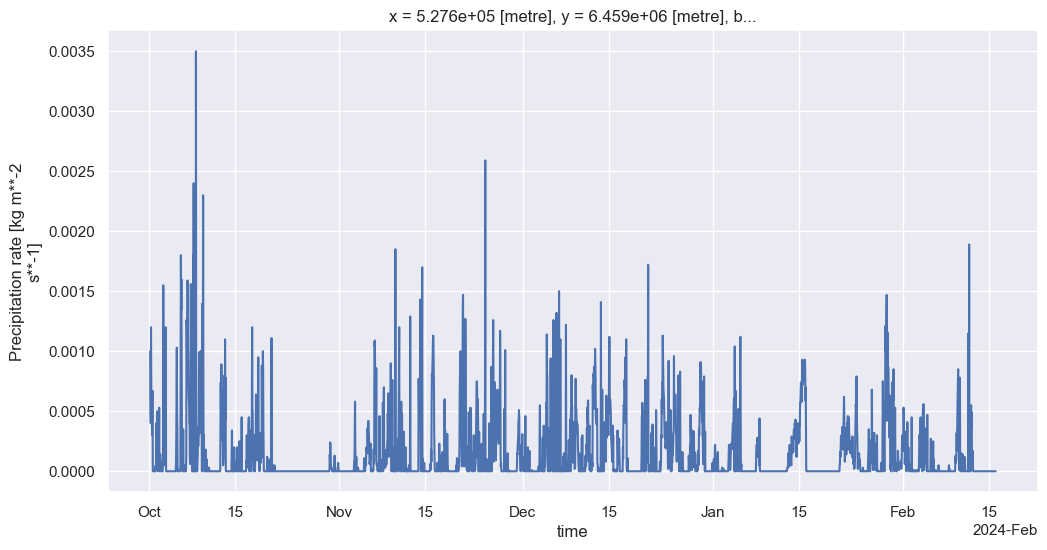

In [5]:
ds.precip_rate.plot()

In [6]:
ds['precip_accum_1hr'] = ds['precip_rate'] * 3600 # convert from mm/s to mm/hr

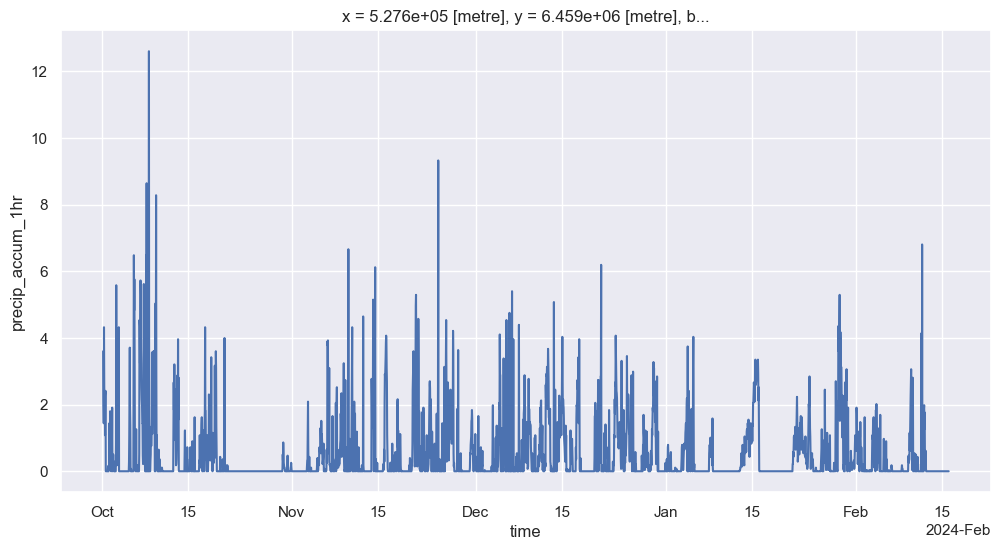

In [7]:
ds['precip_accum_1hr'].plot()

# Load Powder Patch Met Station Data

In [8]:
filename = '/home/cassie/data/fishcreek/mesonet/rawdata/DouglasIsland_AllStations_RawData_WY2024.txt'
# filename = '/home/cassie/data/fishcreek/mesonet/rawdata/DouglasIsland_AllStations_RawData_WY2025_until16March2025.txt'

# open
df = pd.read_csv(filename, sep = ",")

# make utc_valid a datetime and index the df by it 
df['datetime'] = pd.to_datetime(df['utc_valid'])
df = df.set_index('datetime')

# lets only plot PPSA2 station data all together 
# create a new dataframe with only PPSA2 station data
df = df[df['station'] == 'PPSA2']
# drop the columns where all the values are NaN
df = df.dropna(axis=1, how='all')
df.head()

,station,utc_valid,PCIRZZZ,SDIRZZZ,TAIRZZZ,XRIRZZZ
datetime,,,,,,
2023-10-16 18:00:00,PPSA2,2023-10-16 18:00:00,128.62,0.0,49.7,63.04
2023-10-16 19:00:00,PPSA2,2023-10-16 19:00:00,128.62,0.0,50.5,59.44
2023-10-16 20:00:00,PPSA2,2023-10-16 20:00:00,128.62,0.0,48.2,72.65
2023-10-16 21:00:00,PPSA2,2023-10-16 21:00:00,128.62,0.0,48.3,71.85
2023-10-16 22:00:00,PPSA2,2023-10-16 22:00:00,128.62,0.0,48.4,72.42


In [9]:
# cut both datasets to 2023-10-16 18:00:00 and 2024-02-16T04:00:00, which is the period where we have data for both datasets
ds = ds.sel(time=slice('2023-10-16T18:00:00', '2024-02-16T04:00:00'))
df = df[df.index >= '2023-10-16T18:00:00']
df = df[df.index <= '2024-02-16T04:00:00']

<Axes: xlabel='datetime'>

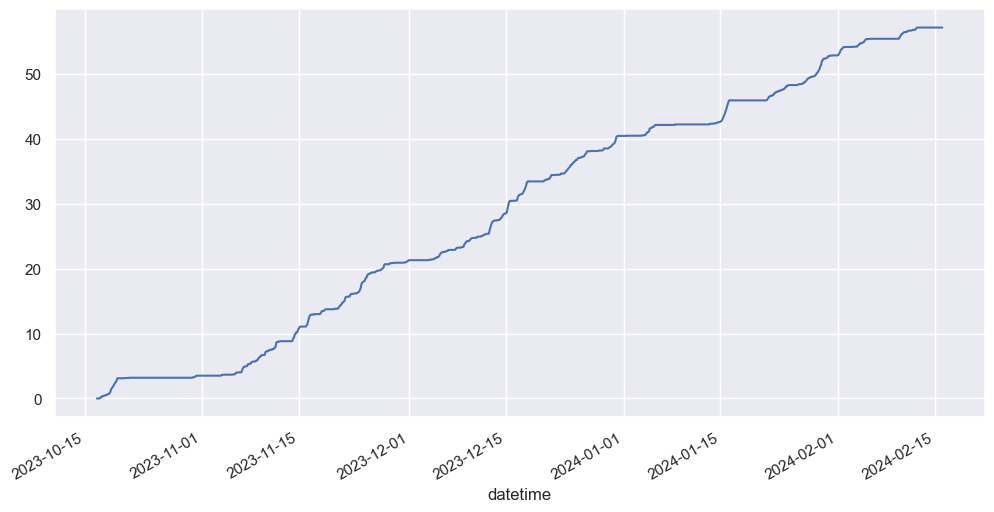

In [10]:
# cleaning to get the WY2024 data useful
df['PCIRZZZ'] = df['PCIRZZZ'].where(df['PCIRZZZ'] < 500) # only keep values less than 500
df['PCIRZZZ'] = df['PCIRZZZ'].where(df['PCIRZZZ'] > 120) # only keep values greater than 50
df['PCIRZZZ'] = df['PCIRZZZ'] - 128.62 # this is because the dataset started at 128.62, so need to reset to compare 
df['PCIRZZZ'].plot()

<Axes: xlabel='datetime'>

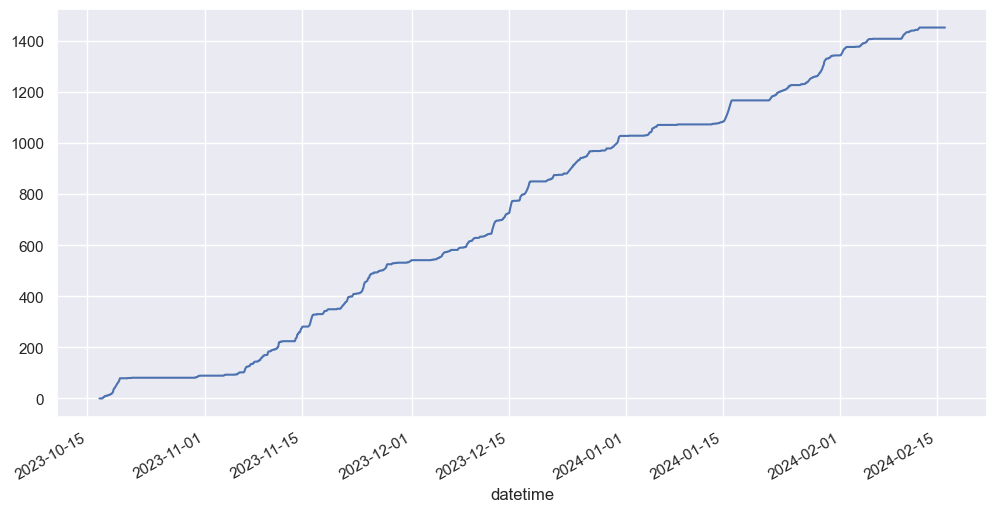

In [11]:
# we want everything in mm, I think PPSA2 is in inches 
df['precip_accum_total'] = df['PCIRZZZ'] * 25.4 # convert from inches to mm
df['precip_accum_total'].plot()

Now, make a `ds['precip_accum_total']` for the HRRR-AK dataset to compare

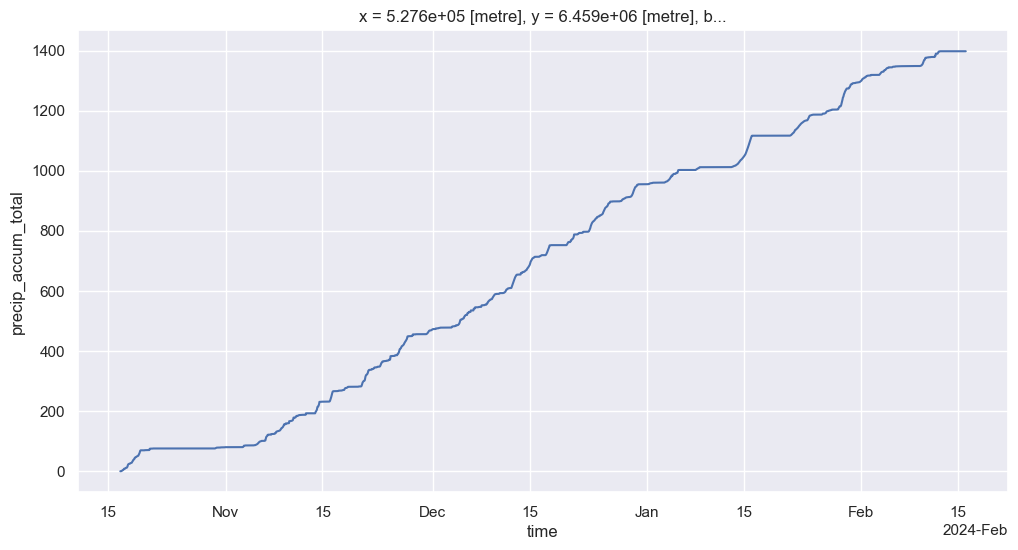

In [12]:
ds['precip_accum_total'] = ds['precip_accum_1hr'].cumsum(dim='time')
ds['precip_accum_total'].plot()

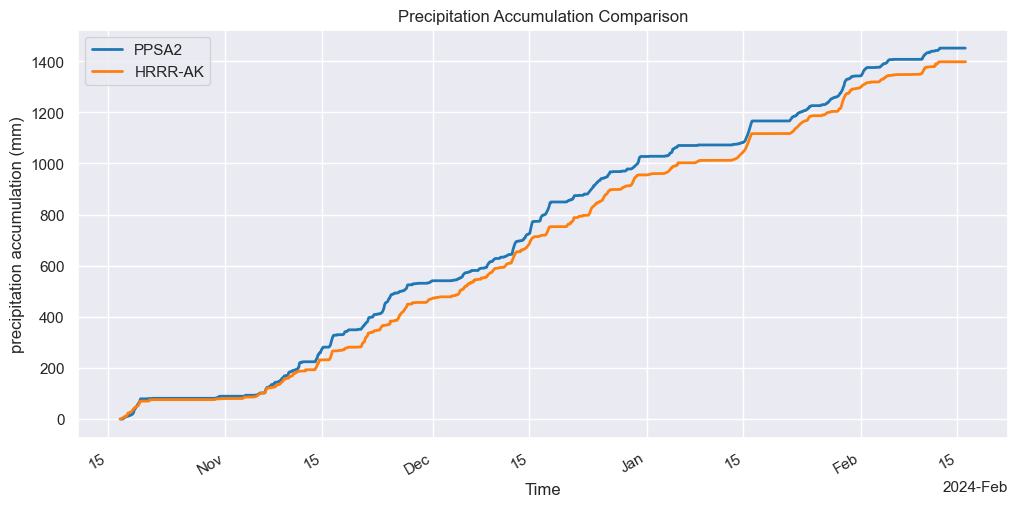

In [13]:
df['precip_accum_total'].plot(label='PPSA2', color='tab:blue', linewidth=2) # obs
ds['precip_accum_total'].plot(label='HRRR-AK', color='tab:orange', linewidth=2) # model

plt.title('Precipitation Accumulation Comparison')
plt.xlabel('Time')
plt.ylabel('precipitation accumulation (mm)')
plt.legend()
plt.show()

### Precipitation Variables from HRRR-AK
`ds.tp` accumulated precipitation since forecast start\
units: kg/m²\
range: 0–20

`ds.precip_rate` is the precipiation rate\
units: kg/m²/s\
range: 0–0.0035

Then, we can create a variable, which would be used in the model, which is the `precip_rate` accumulated over the model timestep (i.e., 1 hr)\
`ds.precip_accum_1hr`

adding to the list now is\
`ds.precip_accum_total` 

In [14]:
df

,station,utc_valid,PCIRZZZ,SDIRZZZ,TAIRZZZ,XRIRZZZ,precip_accum_total
datetime,,,,,,,
2023-10-16 18:00:00,PPSA2,2023-10-16 18:00:00,0.00,0.00,49.7,63.04,0.000
2023-10-16 19:00:00,PPSA2,2023-10-16 19:00:00,0.00,0.00,50.5,59.44,0.000
2023-10-16 20:00:00,PPSA2,2023-10-16 20:00:00,0.00,0.00,48.2,72.65,0.000
2023-10-16 21:00:00,PPSA2,2023-10-16 21:00:00,0.00,0.00,48.3,71.85,0.000
2023-10-16 22:00:00,PPSA2,2023-10-16 22:00:00,0.00,0.00,48.4,72.42,0.000
...,...,...,...,...,...,...,...
2024-02-15 23:00:00,PPSA2,2024-02-15 23:00:00,57.13,78.35,38.2,35.26,1451.102
2024-02-16 00:00:00,PPSA2,2024-02-16 00:00:00,57.13,78.35,37.2,37.65,1451.102
2024-02-16 01:00:00,PPSA2,2024-02-16 01:00:00,57.13,78.54,35.8,43.85,1451.102


In [15]:
# Now, for the met station df, let's create a variable which is the same as ds.precip_rate_accum_1hr, which is the precip_rate converted to mm/hr and then accumulated over time. This way we can compare the same variable between the two datasets.

df['precip_accum_1hr'] = df['precip_accum_total'].diff() # this is the difference between each time step, which should give us the precip_rate in mm/hr since the original precip_accum_total is in mm and the time step is 1 hour. We can then compare this to ds['precip_rate_accum_1hr'] which is the same variable from the model.

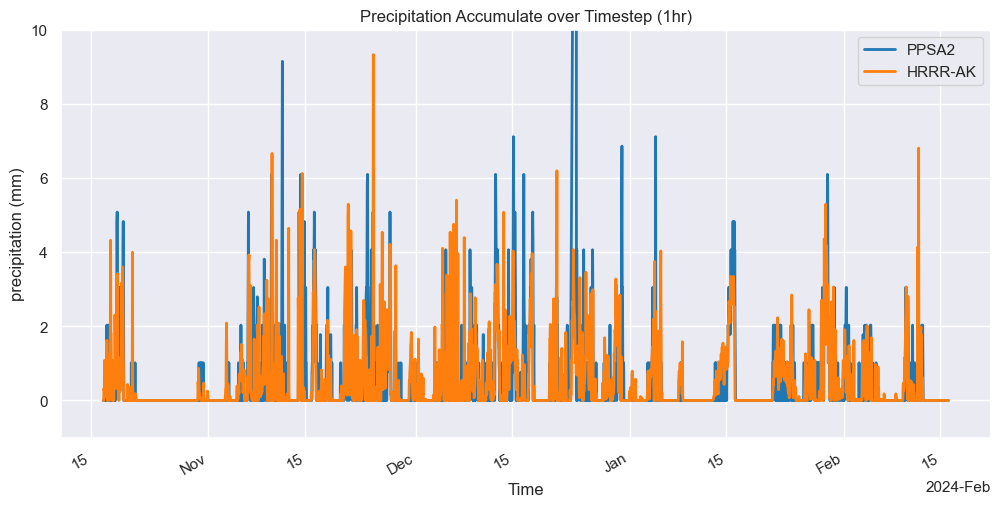

In [16]:
df['precip_accum_1hr'].plot(label='PPSA2', color='tab:blue', linewidth=2) # obs
ds['precip_accum_1hr'].plot(label='HRRR-AK', color='tab:orange', linewidth=2) # model

plt.title('Precipitation Accumulate over Timestep (1hr)')
plt.xlabel('Time')
plt.ylabel('precipitation (mm)')
plt.legend()

plt.ylim(-1,10)
# zoom into a few days 
# plt.xlim('2023-12-01', '2023-12-10')

plt.show()

So, for modeling, df and ds `['precip_accum_1hr']` would be whats used for modeling in timestep = 1hr 

# Compare Other Variables 

In [17]:
df

,station,utc_valid,PCIRZZZ,SDIRZZZ,TAIRZZZ,XRIRZZZ,precip_accum_total,precip_accum_1hr
datetime,,,,,,,,
2023-10-16 18:00:00,PPSA2,2023-10-16 18:00:00,0.00,0.00,49.7,63.04,0.000,NaN
2023-10-16 19:00:00,PPSA2,2023-10-16 19:00:00,0.00,0.00,50.5,59.44,0.000,0.0
2023-10-16 20:00:00,PPSA2,2023-10-16 20:00:00,0.00,0.00,48.2,72.65,0.000,0.0
2023-10-16 21:00:00,PPSA2,2023-10-16 21:00:00,0.00,0.00,48.3,71.85,0.000,0.0
2023-10-16 22:00:00,PPSA2,2023-10-16 22:00:00,0.00,0.00,48.4,72.42,0.000,0.0
...,...,...,...,...,...,...,...,...
2024-02-15 23:00:00,PPSA2,2024-02-15 23:00:00,57.13,78.35,38.2,35.26,1451.102,0.0
2024-02-16 00:00:00,PPSA2,2024-02-16 00:00:00,57.13,78.35,37.2,37.65,1451.102,0.0
2024-02-16 01:00:00,PPSA2,2024-02-16 01:00:00,57.13,78.54,35.8,43.85,1451.102,0.0


In [18]:
# get all the variables consistent first 
df['RH'] = df['XRIRZZZ']
df['HS'] = df['SDIRZZZ'] * 2.54 # convert from inches to mm, this is the snow depth in mm

# lightly clean HS so that no values are over 250cm 
df['HS'] = df['HS'].where(df['HS'] < 250, np.nan)

df['TA'] = (df['TAIRZZZ'] - 32) * 5/9 # convert from F to C


In [19]:
ds

<xarray.Dataset> Size: 717kB
Dimensions:                  (time: 2938)
Coordinates:
  * time                     (time) datetime64[ns] 24kB 2023-10-16T18:00:00 ....
    valid_time               (time) datetime64[ns] 24kB ...
    step                     (time) timedelta64[ns] 24kB ...
    x                        float64 8B ...
    y                        float64 8B ...
    boundaryLayerCloudLayer  float64 8B ...
    spatial_ref              int64 8B 0
Data variables: (12/55)
    pt                       (time) float32 12kB ...
    temp                     (time) float32 12kB ...
    d2m                      (time) float32 12kB ...
    sh2                      (time) float32 12kB ...
    rh                       (time) float32 12kB ...
    u10                      (time) float32 12kB ...
    ...                       ...
    cloud_high               (time) float32 12kB ...
    cloud_low                (time) float32 12kB ...
    wind                     (time) float32 12kB ...
    temp_c                   (time) float32 12kB ...
    precip_accum_1hr         (time) float32 12kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    precip_accum_total       (time) float32 12kB 0.0 0.0 ... 1.398e+03 1.398e+03
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

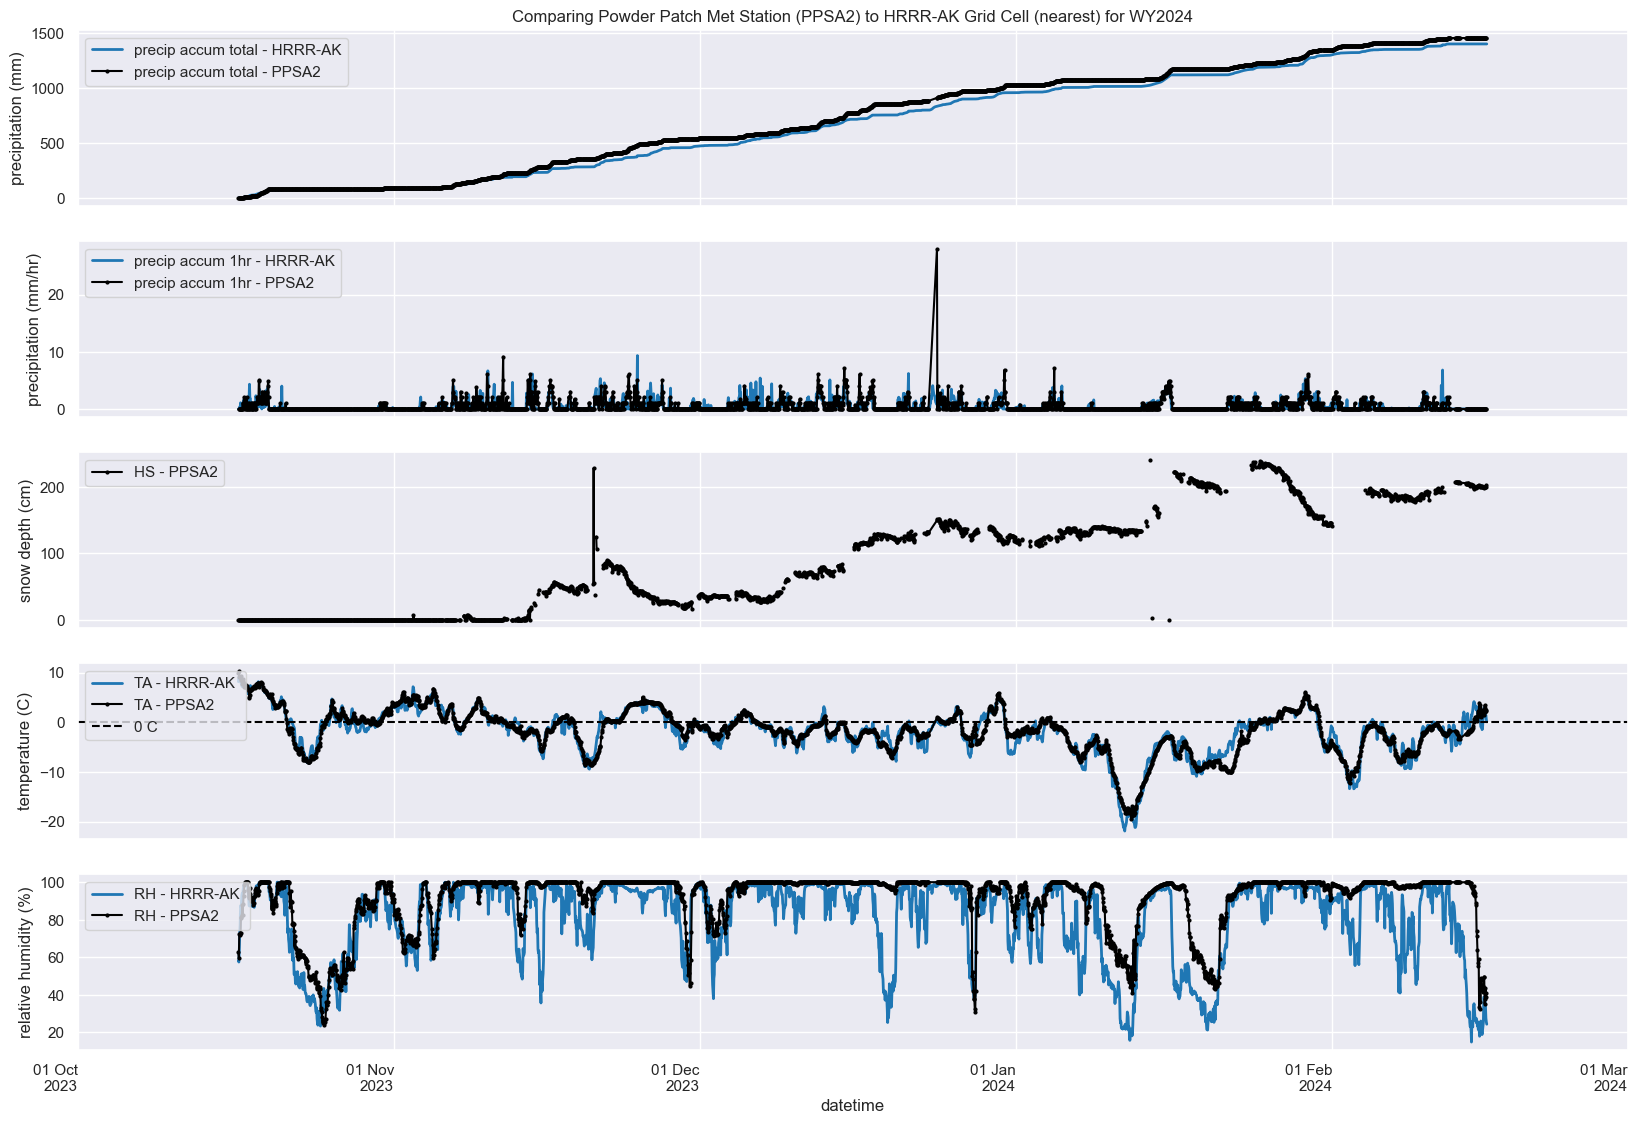

In [20]:
fig, ax = plt.subplots(5, 1, figsize=(20, 15), sharex=True)

# and add in the hrrr-ak variables which match 
ds['precip_accum_total'].plot(ax=ax[0], linestyle='-', label='precip accum total - HRRR-AK', linewidth=2, color='tab:blue')  # mm
ds['precip_accum_1hr'].plot(ax=ax[1], linestyle='-', label='precip accum 1hr - HRRR-AK', linewidth=2, color='tab:blue')  # mm/hr

(ds['temp'] - 273.15).plot(ax=ax[3], linestyle='-', label='TA - HRRR-AK ', linewidth=2, color='tab:blue')  # convert K to C
ds['rh'].plot(ax=ax[4], linestyle='-', label='RH - HRRR-AK ', linewidth=2, color='tab:blue')  # %


# df data 
df['precip_accum_total'].plot(ax=ax[0],marker='o', markersize=2, label='precip accum total - PPSA2', color='black') # mm
df['precip_accum_1hr'].plot(ax=ax[1],marker='o', markersize=2, label='precip accum 1hr - PPSA2', color='black') # mm/hr

df['HS'].plot(ax=ax[2],marker='o', markersize=2, label='HS - PPSA2', color='black') # in inches 
df['TA'].plot(ax=ax[3],marker='o', markersize=2, label='TA - PPSA2', color='black') # now in C
df['RH'].plot(ax=ax[4],marker='o', markersize=2, label='RH - PPSA2', color='black')


ax[3].axhline(y=0, color='black', linestyle='--', label='0 C')

# Labels 
ax[0].set_title('Comparing Powder Patch Met Station (PPSA2) to HRRR-AK Grid Cell (nearest) for WY2024')
ax[1].set_title('')
ax[2].set_title('')
ax[3].set_title('')
ax[4].set_title('')

ax[0].set_ylabel('precipitation (mm)')
ax[1].set_ylabel('precipitation (mm/hr)')
ax[2].set_ylabel('snow depth (cm)')
ax[3].set_ylabel('temperature (C)')
ax[4].set_ylabel('relative humidity (%)')
        
# Set common x-label for all subplots
ax[-1].set_xlabel('datetime')
ax[-1].xaxis.set_major_formatter(dates.DateFormatter('%d %b\n%Y')) #'%d %b\n%Y'
plt.setp(ax[-1].xaxis.get_majorticklabels(), rotation=360)

# select daterange 
start_date = '2023-10-01'
end_date = '2024-03-01'
# Filter the x-axis to show only the specified date range
for a in ax:
    a.set_xlim(pd.to_datetime(start_date), pd.to_datetime(end_date))

# show a legend on all subplots
loc = 'upper left'
ax[0].legend(loc=loc)
ax[1].legend(loc=loc)
ax[2].legend(loc=loc)
ax[3].legend(loc=loc)
ax[4].legend(loc=loc)

plt.show()

There is some missing data, look closer at those dates in December

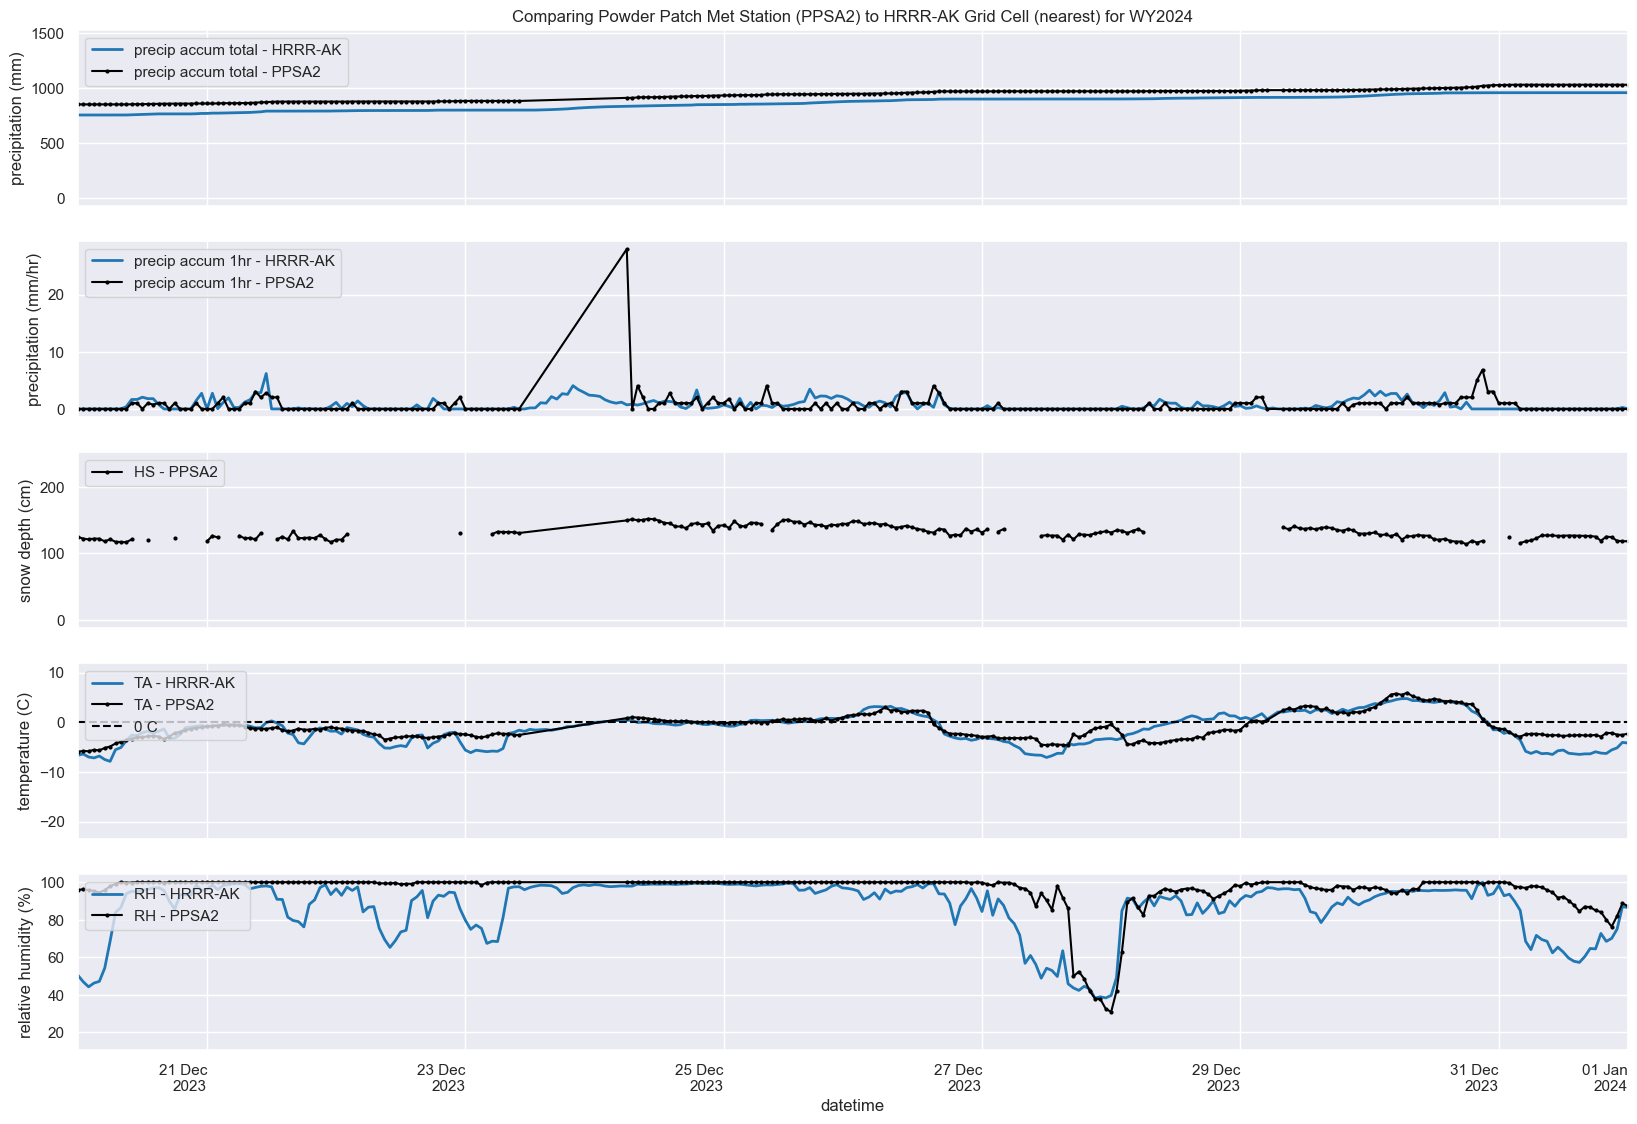

In [21]:
fig, ax = plt.subplots(5, 1, figsize=(20, 15), sharex=True)

# and add in the hrrr-ak variables which match 
ds['precip_accum_total'].plot(ax=ax[0], linestyle='-', label='precip accum total - HRRR-AK', linewidth=2, color='tab:blue')  # mm
ds['precip_accum_1hr'].plot(ax=ax[1], linestyle='-', label='precip accum 1hr - HRRR-AK', linewidth=2, color='tab:blue')  # mm/hr

(ds['temp'] - 273.15).plot(ax=ax[3], linestyle='-', label='TA - HRRR-AK ', linewidth=2, color='tab:blue')  # convert K to C
ds['rh'].plot(ax=ax[4], linestyle='-', label='RH - HRRR-AK ', linewidth=2, color='tab:blue')  # %


# df data 
df['precip_accum_total'].plot(ax=ax[0],marker='o', markersize=2, label='precip accum total - PPSA2', color='black') # mm
df['precip_accum_1hr'].plot(ax=ax[1],marker='o', markersize=2, label='precip accum 1hr - PPSA2', color='black') # mm/hr

df['HS'].plot(ax=ax[2],marker='o', markersize=2, label='HS - PPSA2', color='black') # in inches 
df['TA'].plot(ax=ax[3],marker='o', markersize=2, label='TA - PPSA2', color='black') # now in C
df['RH'].plot(ax=ax[4],marker='o', markersize=2, label='RH - PPSA2', color='black')


ax[3].axhline(y=0, color='black', linestyle='--', label='0 C')

# Labels 
ax[0].set_title('Comparing Powder Patch Met Station (PPSA2) to HRRR-AK Grid Cell (nearest) for WY2024')
ax[1].set_title('')
ax[2].set_title('')
ax[3].set_title('')
ax[4].set_title('')

ax[0].set_ylabel('precipitation (mm)')
ax[1].set_ylabel('precipitation (mm/hr)')
ax[2].set_ylabel('snow depth (cm)')
ax[3].set_ylabel('temperature (C)')
ax[4].set_ylabel('relative humidity (%)')
        
# Set common x-label for all subplots
ax[-1].set_xlabel('datetime')
ax[-1].xaxis.set_major_formatter(dates.DateFormatter('%d %b\n%Y')) #'%d %b\n%Y'
plt.setp(ax[-1].xaxis.get_majorticklabels(), rotation=360)

# select daterange 
start_date = '2023-12-20'
end_date = '2024-01-01'
# Filter the x-axis to show only the specified date range
for a in ax:
    a.set_xlim(pd.to_datetime(start_date), pd.to_datetime(end_date))

# show a legend on all subplots
loc = 'upper left'
ax[0].legend(loc=loc)
ax[1].legend(loc=loc)
ax[2].legend(loc=loc)
ax[3].legend(loc=loc)
ax[4].legend(loc=loc)

plt.show()

Try a method that does diff without the missing data, 

In [22]:
# compute diff
diff = df["precip_accum_total"].diff()

# detect time gaps
time_diff = df.index.to_series().diff().dt.total_seconds()

# mask bad intervals
bad = (
    df["precip_accum_total"].isna() |
    df["precip_accum_total"].shift(1).isna() |
    (time_diff > 3600)
)

df["precip_accum_1hr_mask"] = diff.mask(bad)

Now plot it, 

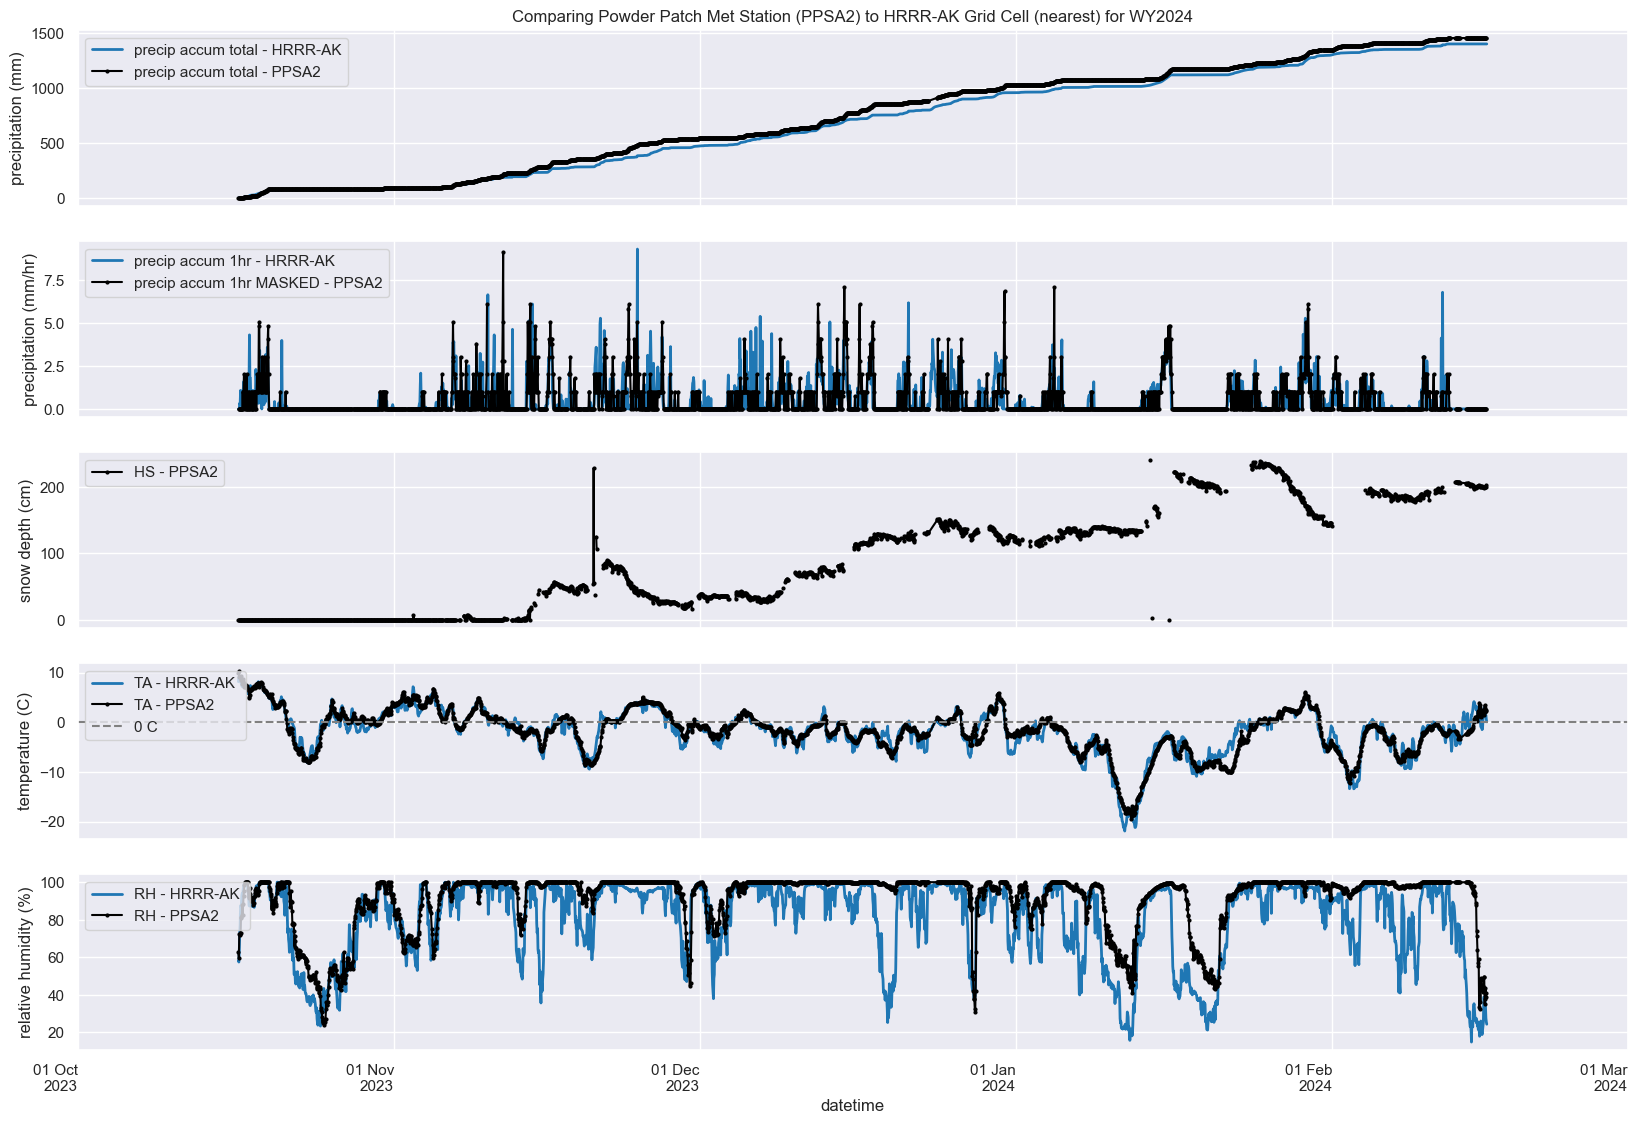

In [24]:
fig, ax = plt.subplots(5, 1, figsize=(20, 15), sharex=True)

# and add in the hrrr-ak variables which match 
ds['precip_accum_total'].plot(ax=ax[0], linestyle='-', label='precip accum total - HRRR-AK', linewidth=2, color='tab:blue')  # mm
ds['precip_accum_1hr'].plot(ax=ax[1], linestyle='-', label='precip accum 1hr - HRRR-AK', linewidth=2, color='tab:blue')  # mm/hr

(ds['temp'] - 273.15).plot(ax=ax[3], linestyle='-', label='TA - HRRR-AK ', linewidth=2, color='tab:blue')  # convert K to C
ds['rh'].plot(ax=ax[4], linestyle='-', label='RH - HRRR-AK ', linewidth=2, color='tab:blue')  # %


# df data 
df['precip_accum_total'].plot(ax=ax[0],marker='o', markersize=2, label='precip accum total - PPSA2', color='black') # mm
df['precip_accum_1hr_mask'].plot(ax=ax[1],marker='o', markersize=2, label='precip accum 1hr MASKED - PPSA2', color='black') # mm/hr

df['HS'].plot(ax=ax[2],marker='o', markersize=2, label='HS - PPSA2', color='black') # in inches 
df['TA'].plot(ax=ax[3],marker='o', markersize=2, label='TA - PPSA2', color='black') # now in C
df['RH'].plot(ax=ax[4],marker='o', markersize=2, label='RH - PPSA2', color='black')


ax[3].axhline(y=0, color='grey', linestyle='--', label='0 C')

# Labels 
ax[0].set_title('Comparing Powder Patch Met Station (PPSA2) to HRRR-AK Grid Cell (nearest) for WY2024')
ax[1].set_title('')
ax[2].set_title('')
ax[3].set_title('')
ax[4].set_title('')

ax[0].set_ylabel('precipitation (mm)')
ax[1].set_ylabel('precipitation (mm/hr)')
ax[2].set_ylabel('snow depth (cm)')
ax[3].set_ylabel('temperature (C)')
ax[4].set_ylabel('relative humidity (%)')
        
# Set common x-label for all subplots
ax[-1].set_xlabel('datetime')
ax[-1].xaxis.set_major_formatter(dates.DateFormatter('%d %b\n%Y')) #'%d %b\n%Y'
plt.setp(ax[-1].xaxis.get_majorticklabels(), rotation=360)

# select daterange 
start_date = '2023-10-01'
end_date = '2024-03-01'
# Filter the x-axis to show only the specified date range
for a in ax:
    a.set_xlim(pd.to_datetime(start_date), pd.to_datetime(end_date))

# show a legend on all subplots
loc = 'upper left'
ax[0].legend(loc=loc)
ax[1].legend(loc=loc)
ax[2].legend(loc=loc)
ax[3].legend(loc=loc)
ax[4].legend(loc=loc)

plt.show()